## Make sure：

si_LL offset ≈ -20 eV
si_CL1 offset ≈ 3 eV #plasmon
si_CL2 offset ≈ 385 eV #N k Edge
si_CL3 offset ≈ 510 eV #O k Edge

dispersion = 0.035 eV

spatial scale = 117.7 nm

In [53]:
# %matplotlib qt

# 01. Data read and check

In [13]:


import hyperspy.api as hs

custom_file = "0008-20260215_1412_(RT, 0.2mol%HNO3)_"
sig_LL = hs.load(f"{custom_file}aligned_si_rezero_LL.hspy")
sig_CL1 = hs.load(f"{custom_file}aligned_si_rezero_CL1.hspy")
sig_CL2 = hs.load(f"{custom_file}aligned_si_rezero_CL2.hspy")
sig_CL3 = hs.load(f"{custom_file}aligned_si_rezero_CL3.hspy")
# sig_CL4 = hs.load(f"{custom_file}aligned_si_rezero_CL4.hspy")
# sig_LL.axes_manager[0].name = "x"
# sig_LL.axes_manager[1].name = "y"
# sig_LL.axes_manager

# sig_LL.axes_manager[0].scale = 20.86
# sig_LL.axes_manager[1].scale = 20.86  # for spatial scale calibration

print(sig_LL)
print(sig_CL1)
print(sig_CL2)
print(sig_CL3)

print(sig_LL.axes_manager)
print(sig_CL1.axes_manager)
print(sig_CL2.axes_manager)
print(sig_CL3.axes_manager)
# print(sig_CL4.axes_manager)


# energy_axis = sig_Oxy.axes_manager.signal_axes[0]
# print("Offset =", energy_axis.offset)

<EELSSpectrum, title: , dimensions: (16, 30|2048)>
<EELSSpectrum, title: , dimensions: (16, 30|2048)>
<EELSSpectrum, title: , dimensions: (16, 30|2048)>
<EELSSpectrum, title: , dimensions: (16, 30|2048)>
<Axes manager, axes: (16, 30|2048)>
            Name |   size |  index |  offset |   scale |  units 
================ | ====== | ====== | ======= | ======= | ====== 
     <undefined> |     16 |      0 |       0 | 1.2e+02 |     nm 
     <undefined> |     30 |      0 |       0 | 1.2e+02 |     nm 
---------------- | ------ | ------ | ------- | ------- | ------ 
     Energy loss |   2048 |      0 |     -19 |   0.035 |     eV 
<Axes manager, axes: (16, 30|2048)>
            Name |   size |  index |  offset |   scale |  units 
================ | ====== | ====== | ======= | ======= | ====== 
     <undefined> |     16 |      0 |       0 | 1.2e+02 |     nm 
     <undefined> |     30 |      0 |       0 | 1.2e+02 |     nm 
---------------- | ------ | ------ | ------- | ------- | ------ 
     Ener

# 02. EELS spectra extraction from corresponding SI

In [9]:
from scipy.signal import savgol_filter

def smooth_signal(sig, window=15, poly=3):
    sig_smooth = sig.copy()
    sig_smooth.data = savgol_filter(sig.data, window_length=window, polyorder=poly)
    return sig_smooth

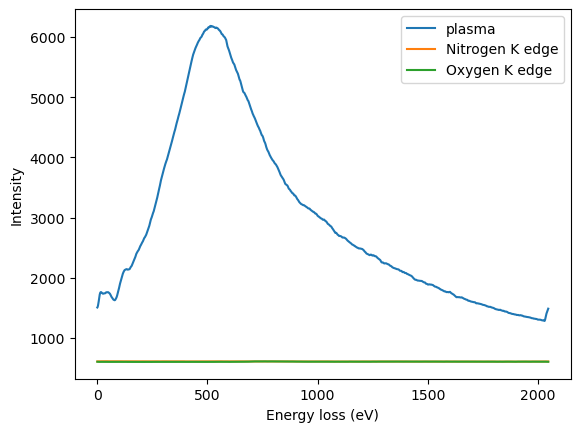

In [11]:
import matplotlib.pyplot as plt

roi_sig_LL = sig_LL.inav[:, :]  # select the whole area of ZLL
roi_sig_CL1 = sig_CL1.inav[:, :]  # select the whole area Plamon
roi_sig_CL2 = sig_CL2.inav[:, :] # N K edge
roi_sig_CL3 = sig_CL3.inav[:, :] # O K edge


# roi_sig_CL1_1 = sig_CL1.inav[:, 65:80] 
# roi_sig_CL1_2 = sig_CL1.inav[:, 25:40]

# roi_sig_CL2_1 = sig_CL2.inav[0:24, 52:58] 
# roi_sig_CL2_2 = sig_CL2.inav[0:24, 40:46] 

mean_spec_LL = roi_sig_LL.mean()
mean_spec_CL1 = roi_sig_CL1.mean()
mean_spec_CL2 = roi_sig_CL2.mean()
mean_spec_CL3 = roi_sig_CL3.mean()



# mean_spec_CL2_1 = roi_sig_CL2_1.mean()
# mean_spec_CL2_2 = roi_sig_CL2_2.mean()

# smoothing
mean_spec_CL1_smooth = smooth_signal(mean_spec_CL1, window=11, poly=3)
mean_spec_CL2_smooth = smooth_signal(mean_spec_CL2, window=11, poly=3)
mean_spec_CL3_smooth = smooth_signal(mean_spec_CL3, window=11, poly=3)


# mean_spec_CL2_1_smooth = smooth_signal(mean_spec_CL2_1, window=11, poly=3)
# mean_spec_CL2_2_smooth = smooth_signal(mean_spec_CL2_2, window=11, poly=3)

# mean_spec_CL2_1_smooth.plot()
# mean_spec_CL2_2_smooth.plot()

import matplotlib.pyplot as plt

plt.figure()

plt.plot(mean_spec_CL1_smooth.data, label="plasma")
plt.plot(mean_spec_CL2_smooth.data, label="Nitrogen K edge")
plt.plot(mean_spec_CL3_smooth.data, label="Oxygen K edge")


plt.legend()
plt.xlabel("Energy loss (eV)")
plt.ylabel("Intensity")

plt.show()

# mean_spec_CL2_1.save(f"{custom_file}aligned_CL2_1_K_enriched.msa", overwrite=True)
# mean_spec_CL2_2.save(f"{custom_file}aligned_CL2_2_K_poor.msa", overwrite=True)
# save
mean_spec_LL.save(f"{custom_file}aligned_LL.msa", overwrite=True)
mean_spec_CL1.save(f"{custom_file}aligned_plama.msa", overwrite=True)
mean_spec_CL2.save(f"{custom_file}aligned_N.msa", overwrite=True)
mean_spec_CL3.save(f"{custom_file}aligned_O.msa", overwrite=True)



# mean_spec_LL.plot()
# mean_spec_CL2.plot()

# mean_spec_LL.save(f"{custom_file}aligned_LL.msa", overwrite=True) # save msa for the plot and analysis in GSM
# mean_spec_CL1.save(f"{custom_file}aligned_CL1.msa", overwrite=True)
# mean_spec_CL2.save(f"{custom_file}aligned_CL2.msa", overwrite=True)
# mean_spec_CL3.save(f"{custom_file}aligned_CL3.msa", overwrite=True)
# mean_spec_CL4.save(f"{custom_file}aligned_CL4.msa", overwrite=True)





# E = mean_spec.axes_manager.signal_axes[0].axis
# I = mean_spec.data

# plt.figure(figsize=(6,4))
# plt.plot(E, I)
# plt.xlabel("Energy loss (eV)")
# plt.ylabel("Intensity (a.u.)")
# plt.title("Mean EELS Spectrum (Low-loss)")
# plt.show()
